In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from scipy.signal import argrelextrema
from scipy.stats import ttest_ind, ttest_1samp, fisher_exact
import statsmodels.api as sm

In [2]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['axes.labelsize'] = 'small'
matplotlib.rcParams['axes.linewidth'] = 1
matplotlib.rcParams['lines.markersize'] = 2
matplotlib.rcParams['xtick.major.width'] = 1
matplotlib.rcParams['ytick.major.width'] = 1
matplotlib.rcParams['xtick.labelsize'] = 'x-small'
matplotlib.rcParams['ytick.labelsize'] = 'x-small'
matplotlib.rcParams['legend.fontsize'] = 'x-small'
matplotlib.rcParams['figure.dpi'] = 600

# 1. Wagner et al. 2011 (https://doi.org/10.1074/mcp.M111.013284)

cutoff = 0.3782


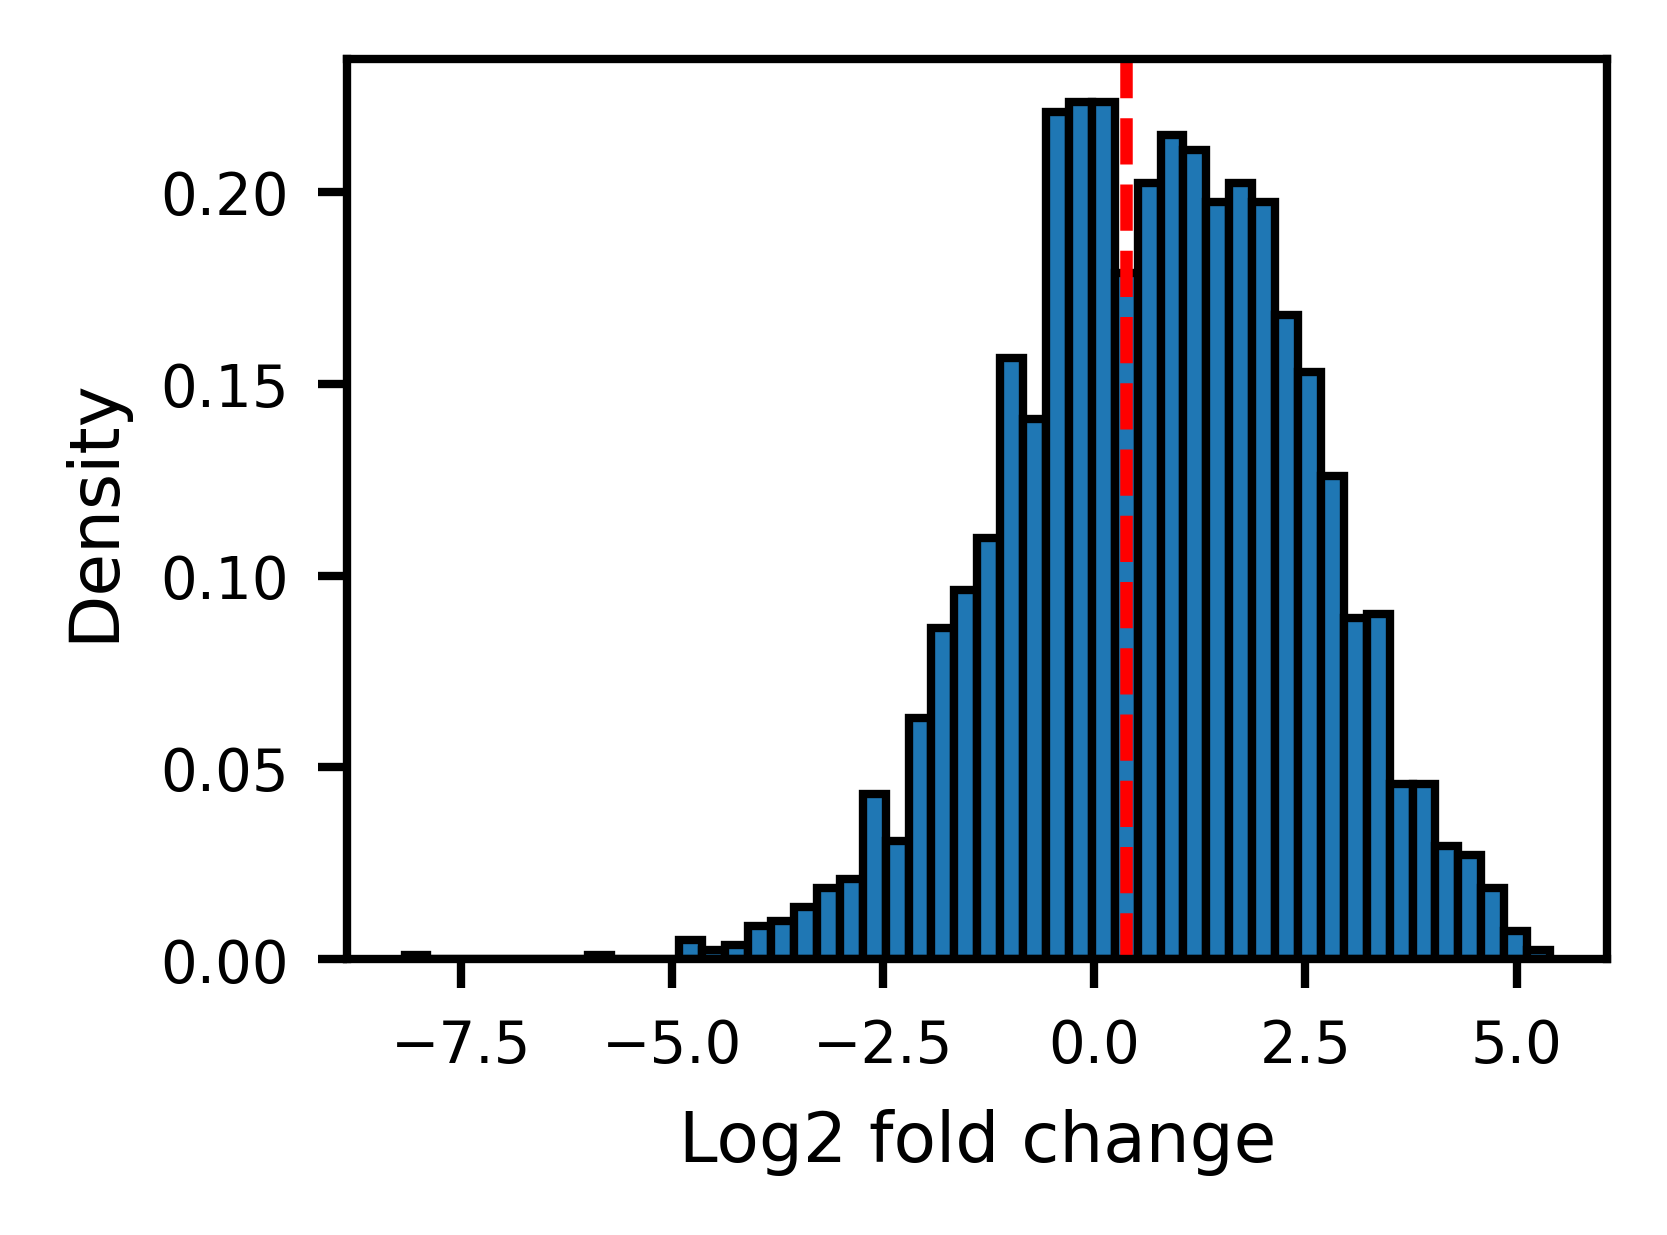

,Uniprot_list,Ubiquitinated
0,A0A962,Y
1,A0AR27,Y
2,A0AUH1,Y
3,A0AUL6,N
4,A0AUY0,Y
...,...,...
10042,Q9Y6P5-3,Y
10043,Q9Y6Q5,Y
10044,Q9Y6Q5-1,Y
10045,Q9Y6Q5-2,Y


In [3]:
data_df = pd.read_excel('./Other_datasets.xlsx', sheet_name='Choudhary', skiprows=1)
data = data_df['Log2 FC for combined (column R)'].to_numpy()
data = data[~np.isnan(data)]

nbins = 50

p, e = np.histogram(data, bins=nbins, density=True)
idx_list = argrelextrema(p, np.less)[0]
cutoff = (e[idx_list] + e[idx_list+1])/2
cutoff = np.min(cutoff[cutoff > 0])
print('cutoff = %.4f'%cutoff)

# Plot distribution
fig = plt.figure(figsize=(3,2))
plt.subplots_adjust(top=0.95, bottom=0.20, left=0.20, hspace=0.30)
ax = fig.add_subplot(1,1,1)
ax.hist(data, bins=nbins, density=True, edgecolor='black')
ylim = ax.get_ylim()
ax.plot([cutoff, cutoff], ylim, '--r')
ax.set_ylim(ylim)
ax.set_xlabel('Log2 fold change')
ax.set_ylabel('Density')
plt.show()

# Label proteins
data_labelled_df = data_df.loc[:,['Uniprot', 'Log2 FC for combined (column R)']]
data_labelled_df["Uniprot_list"] = data_labelled_df["Uniprot"].fillna("").apply(
    lambda x: x.split(";") if x else []
)
data_labelled_df = data_labelled_df.explode("Uniprot_list")
data_labelled_df['Ubiquitinated'] = data_labelled_df['Log2 FC for combined (column R)'].apply(lambda x: 'Y' if pd.notna(x) and x > cutoff else ('N' if pd.notna(x) else np.nan))
data_labelled_df = data_labelled_df.dropna()

UBQ_prot_df = (
    data_labelled_df.loc[:,["Uniprot_list", "Ubiquitinated"]]
    .groupby("Uniprot_list", as_index=False)
    .agg({
        "Ubiquitinated": lambda x: "Y" if (x == "Y").any() else "N"
    })
)

display(UBQ_prot_df)

In [4]:
# Function to merge CCBond lists
def merge_CCBond(series):
    data = []
    for item in series.dropna():
        if isinstance(item, bool):
            data.append(item)
        elif item == 'True':
            data.append(True)
        elif item == 'False':
            data.append(False)
        elif item == '1.0':
            data.append(True)
        elif item == '0.0':
            data.append(False)

    if len(data) > 0:
        if np.any(data): # Any enatnglements are covalent lassos => excluded
            return np.nan
        else:
            return 1
    else:
        return 0

# Parse protein lengths
with open('UP000005640_9606.fasta') as f:
    lines = f.readlines()
prot_len_dict = {}
prot_name_dict = {}
for line in lines:
    line = line.strip()
    if line.startswith('>'):
        uid = line.split('|')[1]
        name = ' '.join(line.split('|')[-1].split('OS=')[0].strip().split()[1:])
        prot_len_dict[uid] = 0
        prot_name_dict[uid] = name
    else:
        prot_len_dict[uid] += len(line)
prot_len_df = pd.DataFrame(list(prot_len_dict.items()), columns=['Uniprot', 'Protein length'])

# Load knotted proteins
knotted_prot_df = pd.read_table('AF4_knots.dat')
knotted_prot_df['Uniprot'] = knotted_prot_df['Uniprot'].apply(lambda x: x.split('-')[0])
human_knotted_prot_df = knotted_prot_df[knotted_prot_df['Organism']=='Human'].copy()
human_knotted_prot_df['Knotted'] = 1

# AlphaFold structures
pLDDT_cutoff = 85
AF_ent_data = pd.read_csv('Human_AF_combined_20250614.csv', sep='|')
AF_ent_data = AF_ent_data[['gene','CCBond']].groupby('gene', as_index=False).agg({'CCBond': merge_CCBond})
AF_ent_data.rename(columns={'gene':'Uniprot',
                            'CCBond':'Entanglement'}, inplace=True)
print('Total %d AF proteins'%AF_ent_data.shape[0])
AF_ent_data = AF_ent_data.merge(human_knotted_prot_df[['Uniprot','Knotted']], on='Uniprot', how='left')
AF_ent_data['Knotted'] = AF_ent_data['Knotted'].fillna(0)
print('Remove %d covalent lassos and %d knots'%(len(AF_ent_data[pd.isna(AF_ent_data['Entanglement'])]),
                                                len(AF_ent_data[AF_ent_data['Knotted']==1])))
AF_ent_data = AF_ent_data.dropna(subset='Entanglement')
AF_ent_data = AF_ent_data.loc[AF_ent_data['Knotted']==0]
print('%d AF proteins left after removal'%AF_ent_data.shape[0])
AF_ent_data = AF_ent_data.merge(prot_len_df, on='Uniprot', how='inner')
AF_ent_data = AF_ent_data.merge(pd.read_csv('Human_Avg_pLDDTs.csv')[['gene','<pLDDT>']], left_on='Uniprot', right_on='gene', how='inner')
print('%d AF proteins left with protein legnth available'%AF_ent_data.shape[0])
AF_ent_data = AF_ent_data.loc[AF_ent_data['<pLDDT>'] >= pLDDT_cutoff]
print('%d AF proteins left with <pLDDT> >= %d'%(AF_ent_data.shape[0], pLDDT_cutoff))

Total 20588 AF proteins
Remove 573 covalent lassos and 125 knots
19914 AF proteins left after removal
19695 AF proteins left with protein legnth available
5641 AF proteins left with <pLDDT> >= 85


In [5]:
label_column_list = ['Ubiquitinated']
label_text_list = ['Ubiquitination']

ent_ubi_df = UBQ_prot_df.merge(
    AF_ent_data[['Uniprot', 'Entanglement', 'Protein length']], 
    left_on="Uniprot_list", right_on="Uniprot", how="inner")
ent_ubi_df = ent_ubi_df.drop(columns=["Uniprot_list"])
display(ent_ubi_df)

for i in range(len(label_column_list)):
    column_name = label_column_list[i]

    # Construct contingency table
    u_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==1)]
    u_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==0)]
    nu_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='N') & (ent_ubi_df['Entanglement']==1)]
    nu_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='N') & (ent_ubi_df['Entanglement']==0)]
    contingency_table = np.array([[u_e.shape[0], nu_e.shape[0]],
                                  [u_ne.shape[0], nu_ne.shape[0]]])
    contingency_table_df = pd.DataFrame(contingency_table, 
                                        columns=[label_text_list[i], 'Non-ubiquitination'], 
                                        index=['Entangled protein', 'Non-entangled protein'])
    contingency_table_df
    display(contingency_table_df)

    # Calculate odds ratio
    odds_ratio, p_value = fisher_exact(contingency_table)

    # Calculate the confidence interval manually
    ln_odds_ratio = np.log(odds_ratio)
    se = np.sqrt(1/contingency_table[0, 0] + 1/contingency_table[0, 1] + 1/contingency_table[1, 0] + 1/contingency_table[1, 1])
    ci = np.exp(ln_odds_ratio + np.array([-1.96, 1.96]) * se)

    print('Fisher\'s exact test:')
    print('Odds Ratio = %.4f, 95%% CI = [%.4f, %.4f], p-value = %.4f'%(odds_ratio, ci[0], ci[1], p_value))

    # Collect data for logistic regression
    clean_df = ent_ubi_df[['Uniprot', 'Entanglement', 'Protein length']].copy()
    labels = []
    for index, row in ent_ubi_df.iterrows():
        if row[column_name] == 'Y':
            label = 1
        elif row[column_name] == 'N':
            label = 0
        else:
            label = np.nan
        labels.append(label)
    clean_df[column_name] = labels
    clean_df['Intercept'] = 1
    # Standardize protein length
    clean_df['Protein length'] = (clean_df['Protein length'] - clean_df['Protein length'].mean()) / clean_df['Protein length'].std()

    clean_df = clean_df.dropna()

    X1 = clean_df[['Intercept', 'Entanglement']]
    X2 = clean_df[['Intercept', 'Entanglement', 'Protein length']]
    y = clean_df[column_name]

    print('Results when protein length is NOT included:')
    model_1 = sm.Logit(y, X1)
    result_1 = model_1.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_1.params,
                                "OR"         : np.exp(result_1.params),
                                "Lower CI"   : np.exp(result_1.conf_int()[0]),
                                "Upper CI"   : np.exp(result_1.conf_int()[1]),
                                "p-value"    : result_1.pvalues}).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

    print('Results when protein length IS included:')
    model_2 = sm.Logit(y, X2)
    result_2 = model_2.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_2.params,
                                "OR"         : np.exp(result_2.params),
                                "Lower CI"   : np.exp(result_2.conf_int()[0]),
                                "Upper CI"   : np.exp(result_2.conf_int()[1]),
                                "p-value"    : result_2.pvalues,
                                "Adjusted p-value": sm.stats.multipletests(result_2.pvalues, method='fdr_bh')[1]}
                              ).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

,Ubiquitinated,Uniprot,Entanglement,Protein length
0,N,A0AVT1,1.0,1052
1,Y,A6NHL2,1.0,446
2,N,A6NMY6,0.0,339
3,Y,A6NNZ2,1.0,444
4,Y,A8MTJ3,1.0,354
...,...,...,...,...
816,N,Q9Y617,1.0,370
817,Y,Q9Y6E2,0.0,419
818,Y,Q9Y6I7,1.0,421
819,Y,Q9Y6Q5,1.0,423


,Ubiquitination,Non-ubiquitination
Entangled protein,439,155
Non-entangled protein,97,130


Fisher's exact test:
Odds Ratio = 3.7958, 95% CI = [2.7551, 5.2297], p-value = 0.0000
Results when protein length is NOT included:


,Coefficient,OR,Lower CI,Upper CI,p-value
Entanglement,1.3339,3.7958,2.7551,5.2297,0.0000


Results when protein length IS included:


,Coefficient,OR,Lower CI,Upper CI,p-value,Adjusted p-value
Entanglement,1.1342,3.1086,2.2031,4.3862,0.0000,0.0000
Protein length,0.3198,1.3769,1.1089,1.7096,0.0038,0.0057


# 2. Kim et al. 2011 (https://doi.org/10.1016/j.molcel.2011.08.025)

## 2.1. Use legacy IPI to Uniprot mapping

In [6]:
def normalize_ipi(x):
    """
    Normalize IPI strings.
    Examples:
        'IPI00012345' -> 'IPI00012345'
        'IPI00012345.1' -> 'IPI00012345'
        'IPI:IPI00012345.1' -> 'IPI00012345'
    """
    if pd.isna(x):
        return None
    x = str(x).strip()
    if not x:
        return None
    if x.startswith("IPI:"):
        x = x[4:]
    x = x.split(".")[0]
    return x


def build_ipi_to_uniprot_map(xref_file, keep_isoforms=False):
    """
    Build a mapping dict:
        IPI -> [UniProt1, UniProt2, ...]

    Based on ipi.HUMAN.xrefs format used in the repository notebook:
        col 0 = source type (SP / TP / ...)
        col 1 = UniProt accession
        col 2 = IPI
    """
    df = pd.read_csv(xref_file, sep="\t", header=None, low_memory=False)
    df = df.dropna(subset=[1, 2]).copy()
    df = df.rename(columns={0: "source", 1: "uniprot_raw", 2: "ipi"})

    df = df[df["source"].isin({"SP", "TP"})].copy()

    df["ipi"] = df["ipi"].map(normalize_ipi)

    if keep_isoforms:
        df["uniprot"] = df["uniprot_raw"].astype(str).str.strip()
    else:
        df["uniprot"] = df["uniprot_raw"].astype(str).str.strip().str.split("-").str[0]
    
    # Remove empty / duplicate pairs
    df = df[df["ipi"].notna() & df["uniprot"].ne("")]
    df = df.drop_duplicates(subset=["ipi", "uniprot"])

    # Group all UniProt hits for each IPI
    mapping = (
        df.groupby("ipi")["uniprot"]
          .agg(lambda x: list(dict.fromkeys(x)))   # unique, preserve order
          .to_dict()
    )

    return mapping


def map_dataset_ipi_to_uniprot(data, xref_file,
                               ipi_col="protein_reference", keep_isoforms=False):
    """
    Read the original dataset, map IPI to all UniProt hits, and return output.
    """

    if ipi_col not in data.columns:
        raise ValueError(f"Column '{ipi_col}' not found in input data. "
                         f"Available columns: {list(data.columns)}")

    # Build mapping from HUMAN xref
    ipi_to_uniprot = build_ipi_to_uniprot_map(xref_file, keep_isoforms=keep_isoforms)

    # Normalize input IPI column
    data["_ipi_norm"] = data[ipi_col].map(normalize_ipi)

    # Map to list
    data["Uniprot_list"] = data["_ipi_norm"].map(lambda x: ipi_to_uniprot.get(x, []))

    # Join as semicolon-separated string
    data["Uniprot"] = data["Uniprot_list"].apply(lambda xs: ";".join(xs) if xs else "")

    # Number of hits
    data["n_uniprot_hits"] = data["Uniprot_list"].apply(len)

    # Optional cleanup
    data = data.drop(columns=["_ipi_norm"])

    return data

data_df = pd.read_excel('./Other_datasets.xlsx', sheet_name='Gygi', skiprows=0)
data_df = map_dataset_ipi_to_uniprot(data_df, './ipi.HUMAN.xrefs', 
                               ipi_col="protein_reference", keep_isoforms=False)
display(data_df)

,protein_reference,site_position,gene_symbol,prot_description,motif_peptide,max_score,H_Btz_8hr_L_0hr_spectral_counts,H_Epox_8hr_L_0hr_spectral_counts,H_Epox_8hr_L_8hr_Btz_spectral_counts,H_Btz_8hr_L_0hr_median,...,H_Btz_8hr_L_0hr_num_quantified,H_Epox_8hr_L_0hr_median,H_Epox_8hr_L_0hr_stDev,H_Epox_8hr_L_0hr_num_quantified,H_Epox_8hr_L_8hr_Btz_median,H_Epox_8hr_L_8hr_Btz_stDev,H_Epox_8hr_L_8hr_Btz_num_quantified,Uniprot_list,Uniprot,n_uniprot_hits
0,IPI:IPI00000005.1,147,NRAS,GTPase NRas,FIETSAKTRQGVE,1000.0000,2,0,1,NaN,...,0,NaN,0.0,0,NaN,0.000000,0,[P01111],P01111,1
1,IPI:IPI00000005.1,128,NRAS,GTPase NRas,TRTVDTKQAHELA,1000.0000,0,3,5,NaN,...,0,NaN,0.0,0,NaN,0.000000,0,[P01111],P01111,1
2,IPI:IPI00000024.2,938,PCDH1,Isoform 1 of Protocadherin-1,GLQKSLKFNLMSD,1000.0000,2,2,1,-1.86669,...,1,-2.34376,0.0,1,-1.77183,0.000000,1,[Q08174],Q08174,1
3,IPI:IPI00000024.2,923,PCDH1,Isoform 1 of Protocadherin-1,KSPKPVKPVEDED,35.7774,5,0,0,NaN,...,0,NaN,0.0,0,NaN,0.000000,0,[Q08174],Q08174,1
4,IPI:IPI00000024.2,935,PCDH1,Isoform 1 of Protocadherin-1,DEAGLQKSLKFNL,32.3052,0,1,0,NaN,...,0,-1.09039,0.0,1,NaN,0.000000,0,[Q08174],Q08174,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8161,IPI:IPI00925575.1,6,RAD18,Protein,xXAGMSQKTVTIT,1000.0000,5,6,7,2.37240,...,2,2.93060,0.0,1,3.04290,0.160545,4,[],,0
8162,IPI:IPI00925595.1,3,PSMD2,Protein,xxxxXGEKDTSLY,1000.0000,5,0,0,-1.24407,...,3,NaN,0.0,0,NaN,0.000000,0,[],,0
8163,IPI:IPI00925754.1,380,USP37,Ubiquitin carboxyl-terminal hydrolase,KLNKTWKTEPVSG,1000.0000,3,1,1,NaN,...,0,NaN,0.0,0,NaN,0.000000,0,[Q86T82],Q86T82,1
8164,IPI:IPI00926449.1,12,RGPD1,Protein,DSNLSVVKKLPVP,1000.0000,3,0,0,2.04643,...,3,NaN,0.0,0,NaN,0.000000,0,[],,0


### 2.1.1. Proteasome inhibited by bortezomib

cutoff = 1.1289


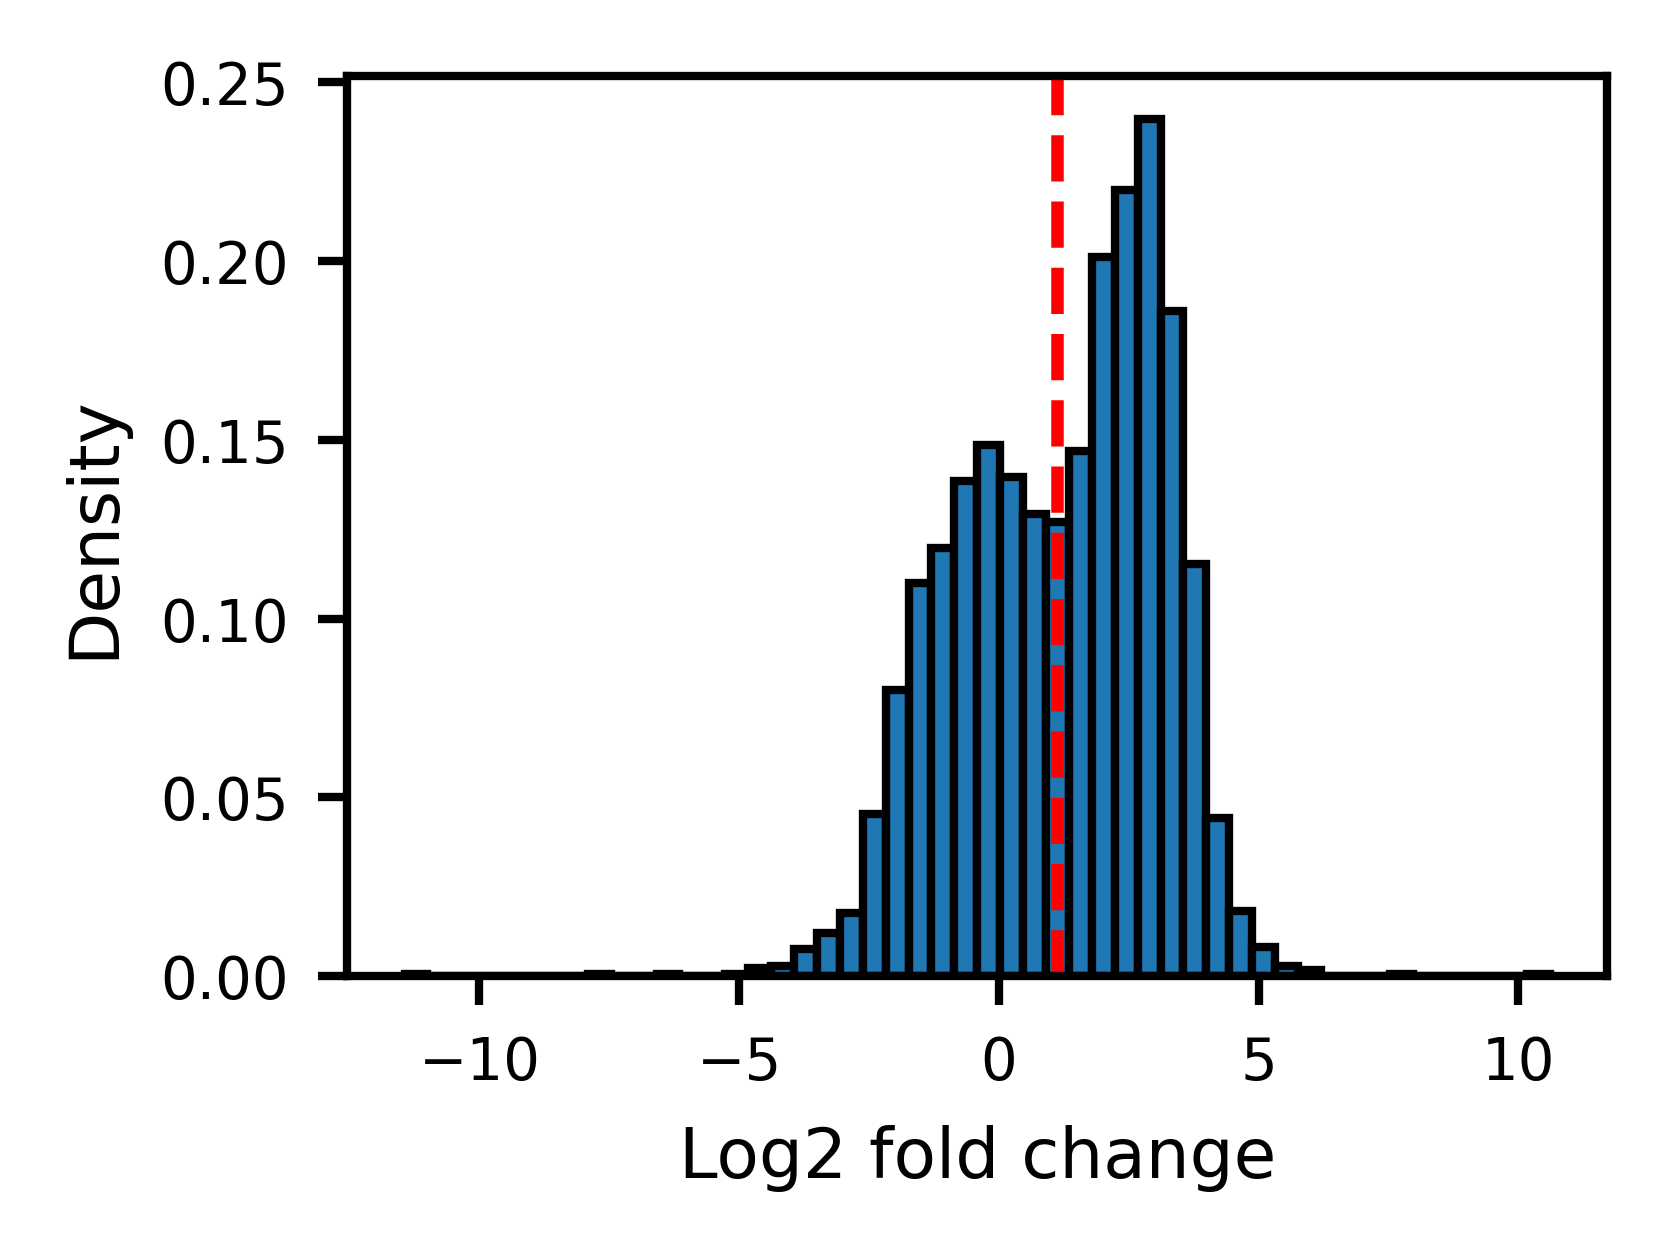

In [7]:
column_name = 'H_Btz_8hr_L_0hr_median'

data = data_df[column_name].to_numpy()
data = data[~np.isnan(data)]

nbins = 50

p, e = np.histogram(data, bins=nbins, density=True)
idx_list = argrelextrema(p, np.less)[0]
cutoff = (e[idx_list] + e[idx_list+1])/2
cutoff = np.min(cutoff[cutoff > 0])
print('cutoff = %.4f'%cutoff)

# Plot distribution
fig = plt.figure(figsize=(3,2))
plt.subplots_adjust(top=0.95, bottom=0.20, left=0.20, hspace=0.30)
ax = fig.add_subplot(1,1,1)
ax.hist(data, bins=nbins, density=True, edgecolor='black')
ylim = ax.get_ylim()
ax.plot([cutoff, cutoff], ylim, '--r')
ax.set_ylim(ylim)
ax.set_xlabel('Log2 fold change')
ax.set_ylabel('Density')
plt.show()

In [8]:
# Label proteins
data_labelled_df = data_df.loc[:,['Uniprot', column_name]]
data_labelled_df["Uniprot_list"] = data_labelled_df["Uniprot"].fillna("").apply(
    lambda x: x.split(";") if x else []
)
data_labelled_df = data_labelled_df.explode("Uniprot_list")
data_labelled_df['Ubiquitinated'] = data_labelled_df[column_name].apply(lambda x: 'Y' if pd.notna(x) and x > cutoff else ('N' if pd.notna(x) else np.nan))
data_labelled_df = data_labelled_df.dropna()

UBQ_prot_df = (
    data_labelled_df.loc[:,["Uniprot_list", "Ubiquitinated"]]
    .groupby("Uniprot_list", as_index=False)
    .agg({
        "Ubiquitinated": lambda x: "Y" if (x == "Y").any() else "N"
    })
)

display(UBQ_prot_df)

,Uniprot_list,Ubiquitinated
0,A0AVF1,Y
1,A0MZ66,N
2,A1XBS5,Y
3,A5PLL7,Y
4,A6NED2,Y
...,...,...
1608,Q9Y6M9,Y
1609,Q9Y6Q5,Y
1610,Q9Y6W3,Y
1611,Q9Y6X2,Y


In [9]:
label_column_list = ['Ubiquitinated']
label_text_list = ['Ubiquitination']

ent_ubi_df = UBQ_prot_df.merge(
    AF_ent_data[['Uniprot', 'Entanglement', 'Protein length']], 
    left_on="Uniprot_list", right_on="Uniprot", how="inner")
ent_ubi_df = ent_ubi_df.drop(columns=["Uniprot_list"])
display(ent_ubi_df)

for i in range(len(label_column_list)):
    column_name = label_column_list[i]

    # Construct contingency table
    u_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==1)]
    u_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==0)]
    nu_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='N') & (ent_ubi_df['Entanglement']==1)]
    nu_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='N') & (ent_ubi_df['Entanglement']==0)]
    contingency_table = np.array([[u_e.shape[0], nu_e.shape[0]],
                                  [u_ne.shape[0], nu_ne.shape[0]]])
    contingency_table_df = pd.DataFrame(contingency_table, 
                                        columns=[label_text_list[i], 'Non-ubiquitination'], 
                                        index=['Entangled protein', 'Non-entangled protein'])
    contingency_table_df
    display(contingency_table_df)

    # Calculate odds ratio
    odds_ratio, p_value = fisher_exact(contingency_table)

    # Calculate the confidence interval manually
    ln_odds_ratio = np.log(odds_ratio)
    se = np.sqrt(1/contingency_table[0, 0] + 1/contingency_table[0, 1] + 1/contingency_table[1, 0] + 1/contingency_table[1, 1])
    ci = np.exp(ln_odds_ratio + np.array([-1.96, 1.96]) * se)

    print('Fisher\'s exact test:')
    print('Odds Ratio = %.4f, 95%% CI = [%.4f, %.4f], p-value = %.4f'%(odds_ratio, ci[0], ci[1], p_value))

    # Collect data for logistic regression
    clean_df = ent_ubi_df[['Uniprot', 'Entanglement', 'Protein length']].copy()
    labels = []
    for index, row in ent_ubi_df.iterrows():
        if row[column_name] == 'Y':
            label = 1
        elif row[column_name] == 'N':
            label = 0
        else:
            label = np.nan
        labels.append(label)
    clean_df[column_name] = labels
    clean_df['Intercept'] = 1
    # Standardize protein length
    clean_df['Protein length'] = (clean_df['Protein length'] - clean_df['Protein length'].mean()) / clean_df['Protein length'].std()

    clean_df = clean_df.dropna()

    X1 = clean_df[['Intercept', 'Entanglement']]
    X2 = clean_df[['Intercept', 'Entanglement', 'Protein length']]
    y = clean_df[column_name]

    print('Results when protein length is NOT included:')
    model_1 = sm.Logit(y, X1)
    result_1 = model_1.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_1.params,
                                "OR"         : np.exp(result_1.params),
                                "Lower CI"   : np.exp(result_1.conf_int()[0]),
                                "Upper CI"   : np.exp(result_1.conf_int()[1]),
                                "p-value"    : result_1.pvalues}).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

    print('Results when protein length IS included:')
    model_2 = sm.Logit(y, X2)
    result_2 = model_2.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_2.params,
                                "OR"         : np.exp(result_2.params),
                                "Lower CI"   : np.exp(result_2.conf_int()[0]),
                                "Upper CI"   : np.exp(result_2.conf_int()[1]),
                                "p-value"    : result_2.pvalues,
                                "Adjusted p-value": sm.stats.multipletests(result_2.pvalues, method='fdr_bh')[1]}
                              ).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

,Ubiquitinated,Uniprot,Entanglement,Protein length
0,Y,A0AVF1,0.0,554
1,Y,A1XBS5,0.0,289
2,Y,A5PLL7,1.0,270
3,Y,A6NED2,1.0,376
4,Y,A6NMY6,0.0,339
...,...,...,...,...
679,Y,Q9Y6B7,1.0,739
680,Y,Q9Y6C9,1.0,303
681,Y,Q9Y6M9,0.0,179
682,Y,Q9Y6Q5,1.0,423


,Ubiquitination,Non-ubiquitination
Entangled protein,357,163
Non-entangled protein,91,73


Fisher's exact test:
Odds Ratio = 1.7570, 95% CI = [1.2265, 2.5168], p-value = 0.0025
Results when protein length is NOT included:


,Coefficient,OR,Lower CI,Upper CI,p-value
Entanglement,0.5636,1.7570,1.2265,2.5168,0.0021


Results when protein length IS included:


,Coefficient,OR,Lower CI,Upper CI,p-value,Adjusted p-value
Entanglement,0.3967,1.4869,1.0198,2.1681,0.0392,0.0392
Protein length,0.3310,1.3924,1.1097,1.7470,0.0042,0.0127


### 2.1.2. Proteasome inhibited by epoxomicin

cutoff = 1.0497


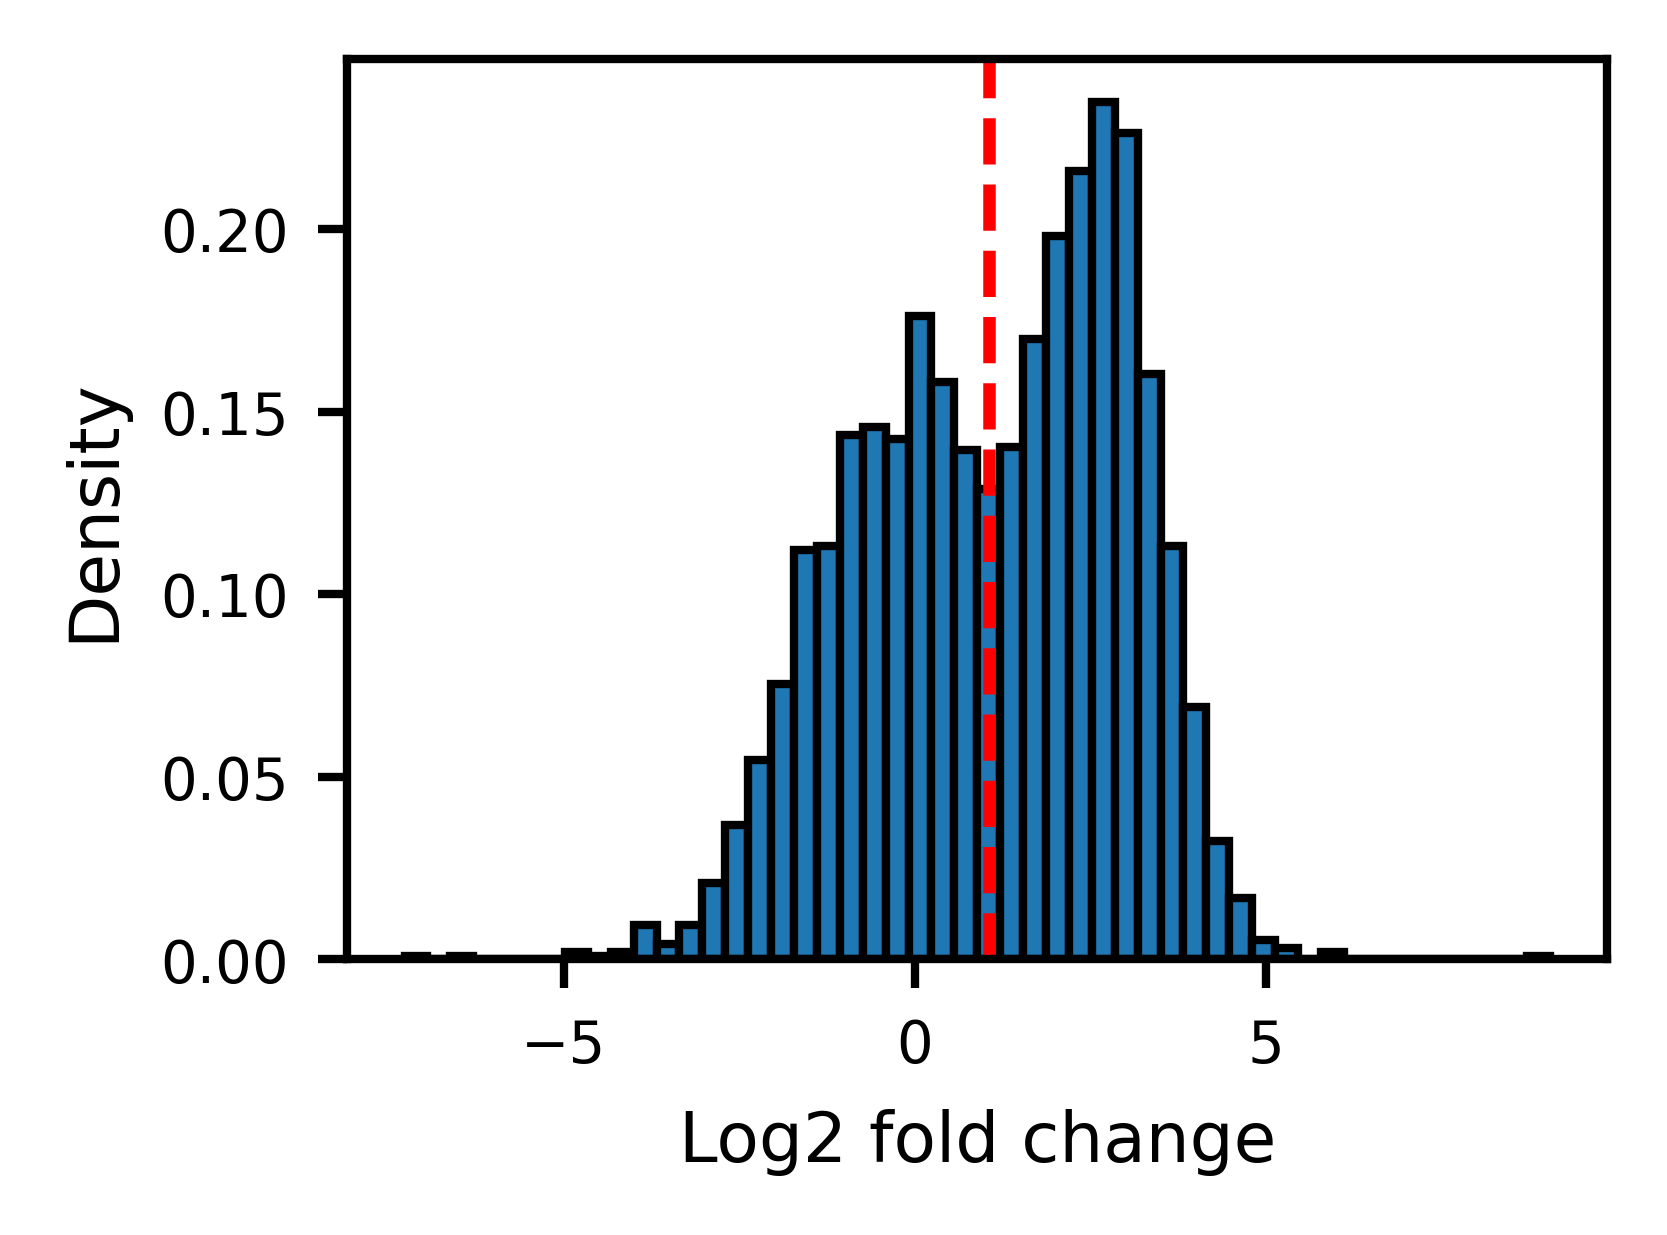

In [10]:
column_name = 'H_Epox_8hr_L_0hr_median'

data = data_df[column_name].to_numpy()
data = data[~np.isnan(data)]

nbins = 50

p, e = np.histogram(data, bins=nbins, density=True)
idx_list = argrelextrema(p, np.less)[0]
cutoff = (e[idx_list] + e[idx_list+1])/2
cutoff = np.min(cutoff[cutoff > 0])
print('cutoff = %.4f'%cutoff)

# Plot distribution
fig = plt.figure(figsize=(3,2))
plt.subplots_adjust(top=0.95, bottom=0.20, left=0.20, hspace=0.30)
ax = fig.add_subplot(1,1,1)
ax.hist(data, bins=nbins, density=True, edgecolor='black')
ylim = ax.get_ylim()
ax.plot([cutoff, cutoff], ylim, '--r')
ax.set_ylim(ylim)
ax.set_xlabel('Log2 fold change')
ax.set_ylabel('Density')
plt.show()

In [11]:
# Label proteins
data_labelled_df = data_df.loc[:,['Uniprot', column_name]]
data_labelled_df["Uniprot_list"] = data_labelled_df["Uniprot"].fillna("").apply(
    lambda x: x.split(";") if x else []
)
data_labelled_df = data_labelled_df.explode("Uniprot_list")
data_labelled_df['Ubiquitinated'] = data_labelled_df[column_name].apply(lambda x: 'Y' if pd.notna(x) and x > cutoff else ('N' if pd.notna(x) else np.nan))
data_labelled_df = data_labelled_df.dropna()

UBQ_prot_df = (
    data_labelled_df.loc[:,["Uniprot_list", "Ubiquitinated"]]
    .groupby("Uniprot_list", as_index=False)
    .agg({
        "Ubiquitinated": lambda x: "Y" if (x == "Y").any() else "N"
    })
)

display(UBQ_prot_df)

,Uniprot_list,Ubiquitinated
0,A0AVF1,Y
1,A0AVT1,N
2,A1XBS5,Y
3,A6NED2,Y
4,A6NMY6,Y
...,...,...
1197,Q9Y6J9,N
1198,Q9Y6K9,N
1199,Q9Y6M1,N
1200,Q9Y6Q5,Y


In [12]:
label_column_list = ['Ubiquitinated']
label_text_list = ['Ubiquitination']

ent_ubi_df = UBQ_prot_df.merge(
    AF_ent_data[['Uniprot', 'Entanglement', 'Protein length']], 
    left_on="Uniprot_list", right_on="Uniprot", how="inner")
ent_ubi_df = ent_ubi_df.drop(columns=["Uniprot_list"])
display(ent_ubi_df)

for i in range(len(label_column_list)):
    column_name = label_column_list[i]

    # Construct contingency table
    u_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==1)]
    u_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==0)]
    nu_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='N') & (ent_ubi_df['Entanglement']==1)]
    nu_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='N') & (ent_ubi_df['Entanglement']==0)]
    contingency_table = np.array([[u_e.shape[0], nu_e.shape[0]],
                                  [u_ne.shape[0], nu_ne.shape[0]]])
    contingency_table_df = pd.DataFrame(contingency_table, 
                                        columns=[label_text_list[i], 'Non-ubiquitination'], 
                                        index=['Entangled protein', 'Non-entangled protein'])
    contingency_table_df
    display(contingency_table_df)

    # Calculate odds ratio
    odds_ratio, p_value = fisher_exact(contingency_table)

    # Calculate the confidence interval manually
    ln_odds_ratio = np.log(odds_ratio)
    se = np.sqrt(1/contingency_table[0, 0] + 1/contingency_table[0, 1] + 1/contingency_table[1, 0] + 1/contingency_table[1, 1])
    ci = np.exp(ln_odds_ratio + np.array([-1.96, 1.96]) * se)

    print('Fisher\'s exact test:')
    print('Odds Ratio = %.4f, 95%% CI = [%.4f, %.4f], p-value = %.4f'%(odds_ratio, ci[0], ci[1], p_value))

    # Collect data for logistic regression
    clean_df = ent_ubi_df[['Uniprot', 'Entanglement', 'Protein length']].copy()
    labels = []
    for index, row in ent_ubi_df.iterrows():
        if row[column_name] == 'Y':
            label = 1
        elif row[column_name] == 'N':
            label = 0
        else:
            label = np.nan
        labels.append(label)
    clean_df[column_name] = labels
    clean_df['Intercept'] = 1
    # Standardize protein length
    clean_df['Protein length'] = (clean_df['Protein length'] - clean_df['Protein length'].mean()) / clean_df['Protein length'].std()

    clean_df = clean_df.dropna()

    X1 = clean_df[['Intercept', 'Entanglement']]
    X2 = clean_df[['Intercept', 'Entanglement', 'Protein length']]
    y = clean_df[column_name]

    print('Results when protein length is NOT included:')
    model_1 = sm.Logit(y, X1)
    result_1 = model_1.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_1.params,
                                "OR"         : np.exp(result_1.params),
                                "Lower CI"   : np.exp(result_1.conf_int()[0]),
                                "Upper CI"   : np.exp(result_1.conf_int()[1]),
                                "p-value"    : result_1.pvalues}).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

    print('Results when protein length IS included:')
    model_2 = sm.Logit(y, X2)
    result_2 = model_2.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_2.params,
                                "OR"         : np.exp(result_2.params),
                                "Lower CI"   : np.exp(result_2.conf_int()[0]),
                                "Upper CI"   : np.exp(result_2.conf_int()[1]),
                                "p-value"    : result_2.pvalues,
                                "Adjusted p-value": sm.stats.multipletests(result_2.pvalues, method='fdr_bh')[1]}
                              ).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

,Ubiquitinated,Uniprot,Entanglement,Protein length
0,Y,A0AVF1,0.0,554
1,N,A0AVT1,1.0,1052
2,Y,A1XBS5,0.0,289
3,Y,A6NED2,1.0,376
4,Y,A6NMY6,0.0,339
...,...,...,...,...
494,N,Q9Y639,1.0,398
495,Y,Q9Y678,1.0,874
496,Y,Q9Y6C9,1.0,303
497,Y,Q9Y6Q5,1.0,423


,Ubiquitination,Non-ubiquitination
Entangled protein,254,124
Non-entangled protein,72,49


Fisher's exact test:
Odds Ratio = 1.3940, 95% CI = [0.9144, 2.1254], p-value = 0.1259
Results when protein length is NOT included:


,Coefficient,OR,Lower CI,Upper CI,p-value
Entanglement,0.3322,1.3940,0.9144,2.1253,0.1226


Results when protein length IS included:


,Coefficient,OR,Lower CI,Upper CI,p-value,Adjusted p-value
Entanglement,0.1538,1.1663,0.7485,1.8173,0.4967,0.4967
Protein length,0.3506,1.4199,1.0797,1.8672,0.0121,0.0182


## 2.2. Use gene name and motif sequence for Uniprot mapping

In [13]:
from Bio import SeqIO
from collections import defaultdict

INPUT_FASTA = "./UP000005640_9606.fasta"

PEPTIDE_COL = "motif_peptide"
GENE_COL = "gene_symbol"
POS_COL = "site_position"

USE_GENE_FILTER = True
MATCH_POSITION = False
POSITION_TOLERANCE = 0         # 0 means exact match; 1 means allow ±1
TARGET_AA = "K"


def parse_uniprot_header(header):
    accession = None
    gene_name = None

    parts = header.split("|")
    if len(parts) >= 3:
        accession = parts[1]

    if " GN=" in header:
        gene_name = header.split(" GN=")[1].split()[0]

    return accession, gene_name


def load_fasta(fasta_file):
    proteins = []
    gene_map = defaultdict(list)

    for rec in SeqIO.parse(fasta_file, "fasta"):
        accession, gene_name = parse_uniprot_header(rec.description)
        seq = str(rec.seq).upper()

        item = {
            "accession": accession,
            "gene": gene_name,
            "sequence": seq,
        }
        proteins.append(item)

        if gene_name:
            gene_map[gene_name].append(item)

    return proteins, gene_map


def clean_motif(x):
    if pd.isna(x):
        return None
    x = str(x).strip().upper()
    if not x:
        return None
    return x


def find_central_k_index(motif, target_aa="K"):
    """
    Prefer the K at the center.
    Fallback: choose the K closest to the center.
    """
    if not motif:
        return None

    center = len(motif) // 2
    if motif[center] == target_aa:
        return center

    k_positions = [i for i, aa in enumerate(motif) if aa == target_aa]
    if not k_positions:
        return None

    return min(k_positions, key=lambda i: abs(i - center))


def motif_matches_at_position(seq, motif, site_pos, center_idx, target_aa="K"):
    """
    Strict mode for MATCH_POSITION=True:
    - non-X chars must match sequence exactly
    - X must be outside sequence termini
    """
    seq_len = len(seq)

    for i, mchar in enumerate(motif):
        seq_pos = site_pos + (i - center_idx)   # 1-based

        if mchar == "X":
            if 1 <= seq_pos <= seq_len:
                return False
            continue

        if not (1 <= seq_pos <= seq_len):
            return False

        if seq[seq_pos - 1] != mchar:
            return False

    if not (1 <= site_pos <= seq_len):
        return False

    if seq[site_pos - 1] != target_aa:
        return False

    return True


def find_hits_with_position(
    motif,
    proteins,
    site_pos=None,
    match_position=True,
    tolerance=0,
    target_aa="K",
):
    hits = []

    center_idx = find_central_k_index(motif, target_aa=target_aa)
    if center_idx is None:
        return []

    for p in proteins:
        seq = p["sequence"]
        seq_len = len(seq)
        matched = False

        if match_position and site_pos is not None:
            for delta in range(-tolerance, tolerance + 1):
                pos = site_pos + delta
                if not (1 <= pos <= seq_len):
                    continue
                if seq[pos - 1] != target_aa:
                    continue

                if motif_matches_at_position(seq, motif, pos, center_idx, target_aa=target_aa):
                    hits.append(p["accession"])
                    matched = True
                    break

        else:
            # Relaxed mode:
            # remove all X and search the remaining substring directly
            motif_no_x = motif.replace("X", "")

            if not motif_no_x:
                continue

            if motif_no_x in seq:
                hits.append(p["accession"])
                matched = True

        if matched:
            continue

    return list(dict.fromkeys(hits))


def map_motif_gene_position(
    df,
    proteins,
    gene_map,
    peptide_col="motif_peptide",
    gene_col="gene_symbol",
    pos_col="site_position",
    use_gene_filter=True,
    match_position=True,
    tolerance=0,
    target_aa="K",
):
    out = df.copy()
    uniprot_lists = []

    for _, row in out.iterrows():
        motif = clean_motif(row.get(peptide_col))
        gene = str(row.get(gene_col)).strip() if pd.notna(row.get(gene_col)) else None

        site_pos = None
        if pd.notna(row.get(pos_col)):
            try:
                site_pos = int(row.get(pos_col))
            except Exception:
                site_pos = None

        if motif is None:
            uniprot_lists.append([])
            continue

        search_space = proteins
        if use_gene_filter and gene and gene in gene_map:
            search_space = gene_map[gene]

        hits = find_hits_with_position(
            motif=motif,
            proteins=search_space,
            site_pos=site_pos,
            match_position=match_position,
            tolerance=tolerance,
            target_aa=target_aa,
        )
        uniprot_lists.append(hits)

    out["Uniprot_list"] = uniprot_lists
    out["Uniprot"] = out["Uniprot_list"].apply(lambda xs: ";".join(xs) if xs else "")
    out["n_hits"] = out["Uniprot_list"].apply(len)

    return out


proteins, gene_map = load_fasta(INPUT_FASTA)
data_df = pd.read_excel('./Other_datasets.xlsx', sheet_name='Gygi', skiprows=0)
data_df = map_motif_gene_position(
        df=data_df,
        proteins=proteins,
        gene_map=gene_map,
        peptide_col=PEPTIDE_COL,
        gene_col=GENE_COL,
        pos_col=POS_COL,
        use_gene_filter=USE_GENE_FILTER,
        match_position=MATCH_POSITION,
        tolerance=POSITION_TOLERANCE,
        target_aa=TARGET_AA,
    )


display(data_df)

,protein_reference,site_position,gene_symbol,prot_description,motif_peptide,max_score,H_Btz_8hr_L_0hr_spectral_counts,H_Epox_8hr_L_0hr_spectral_counts,H_Epox_8hr_L_8hr_Btz_spectral_counts,H_Btz_8hr_L_0hr_median,...,H_Btz_8hr_L_0hr_num_quantified,H_Epox_8hr_L_0hr_median,H_Epox_8hr_L_0hr_stDev,H_Epox_8hr_L_0hr_num_quantified,H_Epox_8hr_L_8hr_Btz_median,H_Epox_8hr_L_8hr_Btz_stDev,H_Epox_8hr_L_8hr_Btz_num_quantified,Uniprot_list,Uniprot,n_hits
0,IPI:IPI00000005.1,147,NRAS,GTPase NRas,FIETSAKTRQGVE,1000.0000,2,0,1,NaN,...,0,NaN,0.0,0,NaN,0.000000,0,[P01111],P01111,1
1,IPI:IPI00000005.1,128,NRAS,GTPase NRas,TRTVDTKQAHELA,1000.0000,0,3,5,NaN,...,0,NaN,0.0,0,NaN,0.000000,0,[P01111],P01111,1
2,IPI:IPI00000024.2,938,PCDH1,Isoform 1 of Protocadherin-1,GLQKSLKFNLMSD,1000.0000,2,2,1,-1.86669,...,1,-2.34376,0.0,1,-1.77183,0.000000,1,[Q08174],Q08174,1
3,IPI:IPI00000024.2,923,PCDH1,Isoform 1 of Protocadherin-1,KSPKPVKPVEDED,35.7774,5,0,0,NaN,...,0,NaN,0.0,0,NaN,0.000000,0,[Q08174],Q08174,1
4,IPI:IPI00000024.2,935,PCDH1,Isoform 1 of Protocadherin-1,DEAGLQKSLKFNL,32.3052,0,1,0,NaN,...,0,-1.09039,0.0,1,NaN,0.000000,0,[Q08174],Q08174,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8161,IPI:IPI00925575.1,6,RAD18,Protein,xXAGMSQKTVTIT,1000.0000,5,6,7,2.37240,...,2,2.93060,0.0,1,3.04290,0.160545,4,[Q9NS91],Q9NS91,1
8162,IPI:IPI00925595.1,3,PSMD2,Protein,xxxxXGEKDTSLY,1000.0000,5,0,0,-1.24407,...,3,NaN,0.0,0,NaN,0.000000,0,[Q13200],Q13200,1
8163,IPI:IPI00925754.1,380,USP37,Ubiquitin carboxyl-terminal hydrolase,KLNKTWKTEPVSG,1000.0000,3,1,1,NaN,...,0,NaN,0.0,0,NaN,0.000000,0,[Q86T82],Q86T82,1
8164,IPI:IPI00926449.1,12,RGPD1,Protein,DSNLSVVKKLPVP,1000.0000,3,0,0,2.04643,...,3,NaN,0.0,0,NaN,0.000000,0,[P0DJD0],P0DJD0,1


### 2.2.1. Proteasome inhibited by bortezomib

In [14]:
column_name = 'H_Btz_8hr_L_0hr_median'

data = data_df[column_name].to_numpy()
data = data[~np.isnan(data)]

nbins = 50

p, e = np.histogram(data, bins=nbins, density=True)
idx_list = argrelextrema(p, np.less)[0]
cutoff = (e[idx_list] + e[idx_list+1])/2
cutoff = np.min(cutoff[cutoff > 0])
print('cutoff = %.4f'%cutoff)

# Label proteins
data_labelled_df = data_df.loc[:,['Uniprot', column_name]]
data_labelled_df["Uniprot_list"] = data_labelled_df["Uniprot"].fillna("").apply(
    lambda x: x.split(";") if x else []
)
data_labelled_df = data_labelled_df.explode("Uniprot_list")
data_labelled_df['Ubiquitinated'] = data_labelled_df[column_name].apply(lambda x: 'Y' if pd.notna(x) and x > cutoff else ('N' if pd.notna(x) else np.nan))
data_labelled_df = data_labelled_df.dropna()

UBQ_prot_df = (
    data_labelled_df.loc[:,["Uniprot_list", "Ubiquitinated"]]
    .groupby("Uniprot_list", as_index=False)
    .agg({
        "Ubiquitinated": lambda x: "Y" if (x == "Y").any() else "N"
    })
)

display(UBQ_prot_df)

label_column_list = ['Ubiquitinated']
label_text_list = ['Ubiquitination']

ent_ubi_df = UBQ_prot_df.merge(
    AF_ent_data[['Uniprot', 'Entanglement', 'Protein length']], 
    left_on="Uniprot_list", right_on="Uniprot", how="inner")
ent_ubi_df = ent_ubi_df.drop(columns=["Uniprot_list"])
display(ent_ubi_df)

for i in range(len(label_column_list)):
    column_name = label_column_list[i]

    # Construct contingency table
    u_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==1)]
    u_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==0)]
    nu_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='N') & (ent_ubi_df['Entanglement']==1)]
    nu_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='N') & (ent_ubi_df['Entanglement']==0)]
    contingency_table = np.array([[u_e.shape[0], nu_e.shape[0]],
                                  [u_ne.shape[0], nu_ne.shape[0]]])
    contingency_table_df = pd.DataFrame(contingency_table, 
                                        columns=[label_text_list[i], 'Non-ubiquitination'], 
                                        index=['Entangled protein', 'Non-entangled protein'])
    contingency_table_df
    display(contingency_table_df)

    # Calculate odds ratio
    odds_ratio, p_value = fisher_exact(contingency_table)

    # Calculate the confidence interval manually
    ln_odds_ratio = np.log(odds_ratio)
    se = np.sqrt(1/contingency_table[0, 0] + 1/contingency_table[0, 1] + 1/contingency_table[1, 0] + 1/contingency_table[1, 1])
    ci = np.exp(ln_odds_ratio + np.array([-1.96, 1.96]) * se)

    print('Fisher\'s exact test:')
    print('Odds Ratio = %.4f, 95%% CI = [%.4f, %.4f], p-value = %.4f'%(odds_ratio, ci[0], ci[1], p_value))

    # Collect data for logistic regression
    clean_df = ent_ubi_df[['Uniprot', 'Entanglement', 'Protein length']].copy()
    labels = []
    for index, row in ent_ubi_df.iterrows():
        if row[column_name] == 'Y':
            label = 1
        elif row[column_name] == 'N':
            label = 0
        else:
            label = np.nan
        labels.append(label)
    clean_df[column_name] = labels
    clean_df['Intercept'] = 1
    # Standardize protein length
    clean_df['Protein length'] = (clean_df['Protein length'] - clean_df['Protein length'].mean()) / clean_df['Protein length'].std()

    clean_df = clean_df.dropna()

    X1 = clean_df[['Intercept', 'Entanglement']]
    X2 = clean_df[['Intercept', 'Entanglement', 'Protein length']]
    y = clean_df[column_name]

    print('Results when protein length is NOT included:')
    model_1 = sm.Logit(y, X1)
    result_1 = model_1.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_1.params,
                                "OR"         : np.exp(result_1.params),
                                "Lower CI"   : np.exp(result_1.conf_int()[0]),
                                "Upper CI"   : np.exp(result_1.conf_int()[1]),
                                "p-value"    : result_1.pvalues}).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

    print('Results when protein length IS included:')
    model_2 = sm.Logit(y, X2)
    result_2 = model_2.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_2.params,
                                "OR"         : np.exp(result_2.params),
                                "Lower CI"   : np.exp(result_2.conf_int()[0]),
                                "Upper CI"   : np.exp(result_2.conf_int()[1]),
                                "p-value"    : result_2.pvalues,
                                "Adjusted p-value": sm.stats.multipletests(result_2.pvalues, method='fdr_bh')[1]}
                              ).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

cutoff = 1.1289


,Uniprot_list,Ubiquitinated
0,A0A087WUL8,N
1,A0A2R8Y619,N
2,A0A8I5KQE6,N
3,A0AAG2TVC3,Y
4,A0AVF1,Y
...,...,...
1896,Q9Y6M9,Y
1897,Q9Y6Q5,Y
1898,Q9Y6W3,Y
1899,Q9Y6X2,Y


,Ubiquitinated,Uniprot,Entanglement,Protein length
0,Y,A0AVF1,0.0,554
1,Y,A1XBS5,0.0,289
2,Y,A5PLL7,1.0,270
3,Y,A6NED2,1.0,376
4,Y,A6NMY6,0.0,339
...,...,...,...,...
834,Y,Q9Y6B7,1.0,739
835,Y,Q9Y6C9,1.0,303
836,Y,Q9Y6M9,0.0,179
837,Y,Q9Y6Q5,1.0,423


,Ubiquitination,Non-ubiquitination
Entangled protein,425,191
Non-entangled protein,109,114


Fisher's exact test:
Odds Ratio = 2.3272, 95% CI = [1.7014, 3.1831], p-value = 0.0000
Results when protein length is NOT included:


,Coefficient,OR,Lower CI,Upper CI,p-value
Entanglement,0.8447,2.3272,1.7014,3.1831,0.0000


Results when protein length IS included:


,Coefficient,OR,Lower CI,Upper CI,p-value,Adjusted p-value
Entanglement,0.6176,1.8545,1.3254,2.5949,0.0003,0.0005
Protein length,0.3841,1.4683,1.1916,1.8093,0.0003,0.0005


### 2.2.2. Proteasome inhibited by epoxomicin

In [15]:
column_name = 'H_Epox_8hr_L_0hr_median'

data = data_df[column_name].to_numpy()
data = data[~np.isnan(data)]

nbins = 50

p, e = np.histogram(data, bins=nbins, density=True)
idx_list = argrelextrema(p, np.less)[0]
cutoff = (e[idx_list] + e[idx_list+1])/2
cutoff = np.min(cutoff[cutoff > 0])
print('cutoff = %.4f'%cutoff)

# Label proteins
data_labelled_df = data_df.loc[:,['Uniprot', column_name]]
data_labelled_df["Uniprot_list"] = data_labelled_df["Uniprot"].fillna("").apply(
    lambda x: x.split(";") if x else []
)
data_labelled_df = data_labelled_df.explode("Uniprot_list")
data_labelled_df['Ubiquitinated'] = data_labelled_df[column_name].apply(lambda x: 'Y' if pd.notna(x) and x > cutoff else ('N' if pd.notna(x) else np.nan))
data_labelled_df = data_labelled_df.dropna()

UBQ_prot_df = (
    data_labelled_df.loc[:,["Uniprot_list", "Ubiquitinated"]]
    .groupby("Uniprot_list", as_index=False)
    .agg({
        "Ubiquitinated": lambda x: "Y" if (x == "Y").any() else "N"
    })
)

display(UBQ_prot_df)

label_column_list = ['Ubiquitinated']
label_text_list = ['Ubiquitination']

ent_ubi_df = UBQ_prot_df.merge(
    AF_ent_data[['Uniprot', 'Entanglement', 'Protein length']], 
    left_on="Uniprot_list", right_on="Uniprot", how="inner")
ent_ubi_df = ent_ubi_df.drop(columns=["Uniprot_list"])
display(ent_ubi_df)

for i in range(len(label_column_list)):
    column_name = label_column_list[i]

    # Construct contingency table
    u_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==1)]
    u_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='Y') & (ent_ubi_df['Entanglement']==0)]
    nu_e = ent_ubi_df.loc[(ent_ubi_df[column_name]=='N') & (ent_ubi_df['Entanglement']==1)]
    nu_ne = ent_ubi_df.loc[(ent_ubi_df[column_name]=='N') & (ent_ubi_df['Entanglement']==0)]
    contingency_table = np.array([[u_e.shape[0], nu_e.shape[0]],
                                  [u_ne.shape[0], nu_ne.shape[0]]])
    contingency_table_df = pd.DataFrame(contingency_table, 
                                        columns=[label_text_list[i], 'Non-ubiquitination'], 
                                        index=['Entangled protein', 'Non-entangled protein'])
    contingency_table_df
    display(contingency_table_df)

    # Calculate odds ratio
    odds_ratio, p_value = fisher_exact(contingency_table)

    # Calculate the confidence interval manually
    ln_odds_ratio = np.log(odds_ratio)
    se = np.sqrt(1/contingency_table[0, 0] + 1/contingency_table[0, 1] + 1/contingency_table[1, 0] + 1/contingency_table[1, 1])
    ci = np.exp(ln_odds_ratio + np.array([-1.96, 1.96]) * se)

    print('Fisher\'s exact test:')
    print('Odds Ratio = %.4f, 95%% CI = [%.4f, %.4f], p-value = %.4f'%(odds_ratio, ci[0], ci[1], p_value))

    # Collect data for logistic regression
    clean_df = ent_ubi_df[['Uniprot', 'Entanglement', 'Protein length']].copy()
    labels = []
    for index, row in ent_ubi_df.iterrows():
        if row[column_name] == 'Y':
            label = 1
        elif row[column_name] == 'N':
            label = 0
        else:
            label = np.nan
        labels.append(label)
    clean_df[column_name] = labels
    clean_df['Intercept'] = 1
    # Standardize protein length
    clean_df['Protein length'] = (clean_df['Protein length'] - clean_df['Protein length'].mean()) / clean_df['Protein length'].std()

    clean_df = clean_df.dropna()

    X1 = clean_df[['Intercept', 'Entanglement']]
    X2 = clean_df[['Intercept', 'Entanglement', 'Protein length']]
    y = clean_df[column_name]

    print('Results when protein length is NOT included:')
    model_1 = sm.Logit(y, X1)
    result_1 = model_1.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_1.params,
                                "OR"         : np.exp(result_1.params),
                                "Lower CI"   : np.exp(result_1.conf_int()[0]),
                                "Upper CI"   : np.exp(result_1.conf_int()[1]),
                                "p-value"    : result_1.pvalues}).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

    print('Results when protein length IS included:')
    model_2 = sm.Logit(y, X2)
    result_2 = model_2.fit(disp=0)
    odds_ratios = pd.DataFrame({"Coefficient": result_2.params,
                                "OR"         : np.exp(result_2.params),
                                "Lower CI"   : np.exp(result_2.conf_int()[0]),
                                "Upper CI"   : np.exp(result_2.conf_int()[1]),
                                "p-value"    : result_2.pvalues,
                                "Adjusted p-value": sm.stats.multipletests(result_2.pvalues, method='fdr_bh')[1]}
                              ).drop(index="Intercept", errors="ignore")
    pd.options.display.float_format = '{:.4f}'.format
    display(odds_ratios)
    pd.reset_option('display.float_format')

cutoff = 1.0497


,Uniprot_list,Ubiquitinated
0,A0A2R8Y619,N
1,A0AVF1,Y
2,A0AVT1,N
3,A1XBS5,Y
4,A6NED2,Y
...,...,...
1434,Q9Y6J9,N
1435,Q9Y6K9,N
1436,Q9Y6M1,N
1437,Q9Y6Q5,Y


,Ubiquitinated,Uniprot,Entanglement,Protein length
0,Y,A0AVF1,0.0,554
1,N,A0AVT1,1.0,1052
2,Y,A1XBS5,0.0,289
3,Y,A6NED2,1.0,376
4,Y,A6NMY6,0.0,339
...,...,...,...,...
628,N,Q9Y639,1.0,398
629,Y,Q9Y678,1.0,874
630,Y,Q9Y6C9,1.0,303
631,Y,Q9Y6Q5,1.0,423


,Ubiquitination,Non-ubiquitination
Entangled protein,312,149
Non-entangled protein,95,77


Fisher's exact test:
Odds Ratio = 1.6972, 95% CI = [1.1860, 2.4287], p-value = 0.0051
Results when protein length is NOT included:


,Coefficient,OR,Lower CI,Upper CI,p-value
Entanglement,0.5290,1.6972,1.1861,2.4287,0.0038


Results when protein length IS included:


,Coefficient,OR,Lower CI,Upper CI,p-value,Adjusted p-value
Entanglement,0.3076,1.3602,0.9237,2.0030,0.1192,0.1192
Protein length,0.3625,1.4369,1.1237,1.8373,0.0039,0.0116
